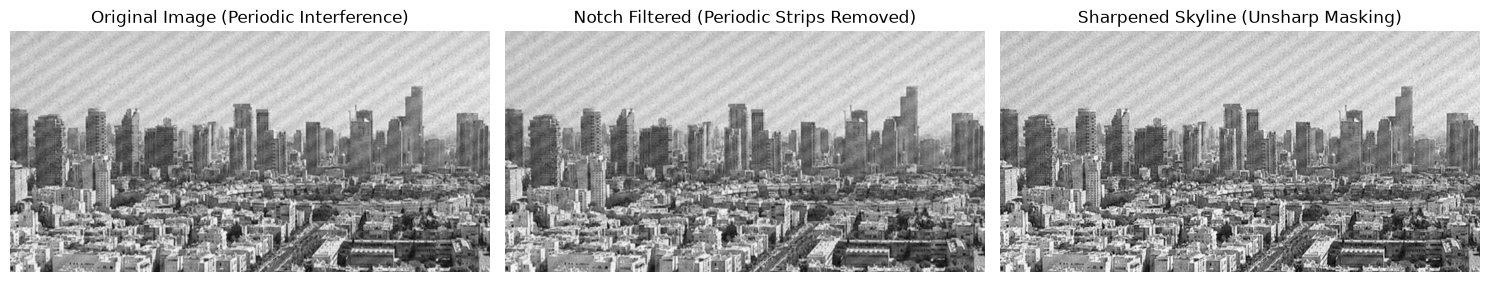

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Load city skyline image corrupted by periodic diagonal striping
image_path = r"C:\Users\Dev Radia\Pictures\Screenshots\image3.png"
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

if image is None:
    print("Error: Image not found. Check the path!")
else:
    # 1. Frequency Domain Processing: 2D FFT to eliminate periodic diagonal noise
    dft = np.fft.fft2(image)
    dft_shift = np.fft.fftshift(dft)

    # Compute magnitude spectrum for visualization
    magnitude_spectrum = 20 * np.log(np.abs(dft_shift) + 1)

    # Create a notch reject filter to suppress periodic frequency spikes
    rows, cols = image.shape
    crow, ccol = rows // 2, cols // 2
    mask = np.ones((rows, cols), np.uint8)

    # Estimate and notch out the conjugate frequency peaks of diagonal ripples
    # Setting notch radius and symmetric notch coordinates around the center
    notch_radius = 5
    notch_coords = [
        (crow - 28, ccol + 38),
        (crow + 28, ccol - 38)
    ]

    for nr, nc in notch_coords:
        cv2.circle(mask, (nc, nr), notch_radius, 0, -1)

    # Apply mask and compute Inverse FFT
    fshift_filtered = dft_shift * mask
    f_ishift = np.fft.ifftshift(fshift_filtered)
    image_denoised = np.fft.ifft2(f_ishift)
    image_denoised = np.abs(image_denoised)
    image_denoised = np.clip(image_denoised, 0, 255).astype(np.uint8)

    # 2. Spatial Sharpening: Unsharp Masking to recover crisp architectural lines
    gaussian_blur = cv2.GaussianBlur(image_denoised, (5, 5), 1.0)
    sharpened_image = cv2.addWeighted(image_denoised, 1.5, gaussian_blur, -0.5, 0)

    # 3. Display the processing stages
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(image, cmap="gray")
    plt.title("Original Image (Periodic Interference)")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(image_denoised, cmap="gray")
    plt.title("Notch Filtered (Periodic Strips Removed)")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(sharpened_image, cmap="gray")
    plt.title("Sharpened Skyline (Unsharp Masking)")
    plt.axis("off")

    plt.tight_layout()
    plt.show()